In [2]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import scipy, scipy.ndimage
import seaborn as sns
from tqdm.notebook import tqdm
import copy


data_dir = 'Data'

# 1. GIST Descriptor and Gabor filters


Gist descriptors summarize the overall “look” or structure of an image, rather than focusing on individual objects or fine details. They provide a high-level, low-dimensional representation of properties like dominant orientations, coarse textures and spatial layout.

The Gist decriptors are obtained from an image by dividing it into a coarse grid. For each cell of the grid, i concatenate the respective average responses of the cell to a set of Gabor filters. I will use a 4x4 grid and a set of 30 Gabor filters (6 different orientations and 5 different scale values).

An image is then discribed by a vector of $4\times4\times6\times5=480$ features.

In practice, this translates into:

1. Define a set of Gabor filters.
2. Resize the image to a fixed size and

To obtain the contours, we must first define a set of Gabor filters.



A Gabor filter is fully described by the four parameters σx, σy, λ and θ according to the following equation:

\begin{equation}
    \begin{aligned}
        &G_{\{\sigma_x, \sigma_y, \lambda, \theta\}}(x,y) = \frac{1}{2\pi\sigma_{x}\sigma_{y}} \exp\left(\frac{-x'^2}{2\sigma_{x}^2}\right)\exp\left(\frac{-y'^2}{2\sigma_{y}^2}\right)\sin\left(2\pi \frac{x'}{\lambda}\right)\\
        &\text{where } \left\{\begin{aligned}
                                x' = x\cos(\theta) - y\sin(\theta)\\
                                y' = x\sin(\theta) + y\cos(\theta)
                            \end{aligned}\right.
    \end{aligned}
\end{equation}


In [ ]:
class DescGIST():
    def __init__(self):
        self.nb_orientations = 6    # Number of orientations of our filters
        self.nb_scales = 5          # Number of scales of our filters
        self.grid_size = 4          # Response of an image to our descriptor will be resiezd to a grid of size 4x4

        self.filter_size = 64       # Each filter will be of size filter_size x filter_size
        self.imsize=128             # Input images will be resized during description
        self.filters = np.zeros((self.filter_size, self.filter_size, self.nb_scales, self.nb_orientations)) #Where we will store our filter
        self.values = np.zeros((self.grid_size, self.grid_size, self.nb_scales, self.nb_orientations)) # Where we will store the response of an image to the descriptor


    def get_gabor(self, theta: float, lda: float, sigma_x: float, sigma_y: float) -> np.ndarray:
        """Returns a Gabor filter for the specified inputs
        """

        X = np.tile(np.linspace(-self.filter_size/2, self.filter_size/2, self.filter_size), (self.filter_size, 1))
        Y = X.copy().T

        Xp = X*np.cos(theta) - Y*np.sin(theta)
        Yp = X*np.sin(theta) + Y*np.cos(theta)

        gabor = (1/(2*np.pi*sigma_x*sigma_y)) * \
                np.exp(-(Xp**2)/(2*sigma_x**2)) * \
                np.exp(-(Yp**2)/(2*sigma_y**2)) * \
                np.sin((2*np.pi*Xp)/lda)

        return gabor


    def get_all_gabors(self) -> np.ndarray:
        """Computes a set of Gabor filters (4D np.array)
        """
        filters = np.zeros_like(self.filters)

        for scale in range(self.nb_scales):

            s = self.filter_size / (2**(scale+1))
            lda = s
            sigma_y = s
            sigma_x = s/2

            for orientation in range(self.nb_orientations):

                theta = orientation * np.pi / self.nb_orientations

                filters[:, :, scale, orientation] = self.get_gabor(
                    theta,
                    lda,
                    sigma_x,
                    sigma_y
                )

        self.filters = filters
        return filters


    def display_filters(self) -> None:
        """Simple function for visualising your computed filters
        """
        filters = self.filters
        h,w,n,m = filters.shape
        s = np.zeros((h*n, w*m))
        for y in range(n):
            for x in range (m):
                filter = filters[:,:,y,x]
                filter = filter / np.max(np.abs(filter))

                s[y*w:(y+1)*w, x*h:(x+1)*h] = filter
        f = plt.gcf()
        plt.axis("off")
        plt.imshow(s, cmap='gray')
        return f

    def describe(self, image: np.ndarray) -> None:
        """Computes the response of an image to the filters stored in self.filters
        """
        if len(image.shape) >= 3 and image.shape[-1] > 1:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        values = np.zeros_like(self.values)

        image = cv2.resize(image, (self.imsize, self.imsize))
        image = image.astype(np.float32)

        for scale in range(self.nb_scales):
            for orientation in range(self.nb_orientations):

                filt = self.filters[:, :, scale, orientation]

                response = scipy.ndimage.correlate(image, filt)

                response = np.abs(response)

                grid_response = cv2.resize(
                    response,
                    (self.grid_size, self.grid_size),
                    interpolation=cv2.INTER_AREA
                )

                values[:, :, scale, orientation] = grid_response

        self.values = values


    def distance(self, d2: 'DescGIST') -> float:
        """Computes the distance between the object and another object of class descriptor
        """
        return np.linalg.norm(self.values - d2.values)

    def display(self) -> None:
        """
        A method for visualising the response of an image to the descriptor.
        Recall that the response is a grid of size (grid_size x grid_size).
        For each cell of that grid, sum the response of the image for every scale and orientation.
        I also flip twice (horizontally and vertically) the responses to account for symmetry.
        """
        if not np.any(self.values):
            print("Descriptor values haven't been computed")
            return False
        s = 256
        res = np.zeros((self.grid_size*s,self.grid_size*s))
        # Initialise diagram
        x = np.tile(np.linspace(-1, 1, s), (s, 1))
        y = x.copy().T

        theta = np.arctan2(y,x)
        r = np.sqrt(x**2 + y**2)
        for i in range(self.grid_size):
            for j in range(self.grid_size):
                diagram = np.zeros((s, s))

                for scale in range(self.nb_scales):
                    for orientation in range(self.nb_orientations):
                        frag = np.ones((s, s))
                        orientationValue = (orientation/self.nb_orientations) * np.pi
                        orientationDistance = np.min((np.abs(theta - orientationValue), np.abs(theta - orientationValue + 2*np.pi)), axis = 0)
                        frag[orientationDistance > 2*np.pi/self.nb_orientations] = 0
                        frag[r < 0.8*((scale/self.nb_scales)**0.7) +0.1] = 0
                        frag[r > 0.8*(((scale+1)/self.nb_scales)**0.7) +0.1] = 0

                        #symetry
                        frag += np.flip(np.flip(frag, 0), 1)
                        diagram += frag*self.values[i, j, scale, orientation]

                res[i*s:(i+1)*s, j*s: (j+1)*s] = diagram
        f = plt.gcf()
        plt.imshow(res)
        plt.axis("off")

        return f



### 1.2. Visualizing all gabor filters

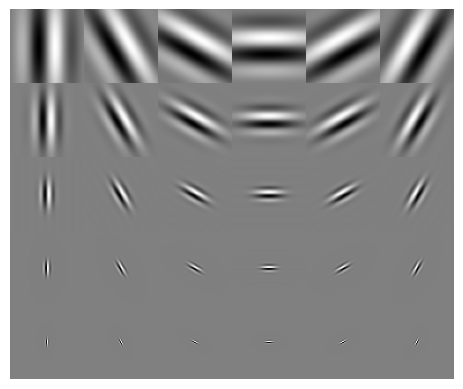

In [4]:
d =DescGIST()
d.get_all_gabors()
f = d.display_filters()
f.savefig("filters.png")

### 1.3. Visualizing the response of an image to our filters

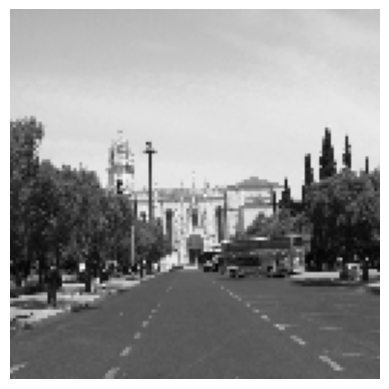

In [5]:
im = cv2.imread(data_dir+"/testGist/street.jpg")
# We resize outside of describe only as an example
grayscale = cv2.resize(cv2.cvtColor(im, cv2.COLOR_BGR2GRAY), (128,128))
grayscale = cv2.normalize(grayscale, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
f = plt.gcf()

plt.imshow(grayscale, cmap='gray')
plt.axis("off")
f.savefig("grayscale.png", dpi=100)

#### Visualizing a response to a single filter

In [6]:
def draw_grid(img, rows, cols, thickness=1):
    h, w = img.shape
    dy, dx = h / rows, w / cols

    for x in np.linspace(start=dx, stop=w-dx, num=cols-1):
        cv2.line(img, (int(x), 0), (int(x), h), color=1, thickness=thickness)

    for y in np.linspace(start=dy, stop=h-dy, num=rows-1):
        cv2.line(img, (0, int(y)), (w, int(y)), color=1, thickness=thickness)

    return img

<Figure size 640x480 with 0 Axes>

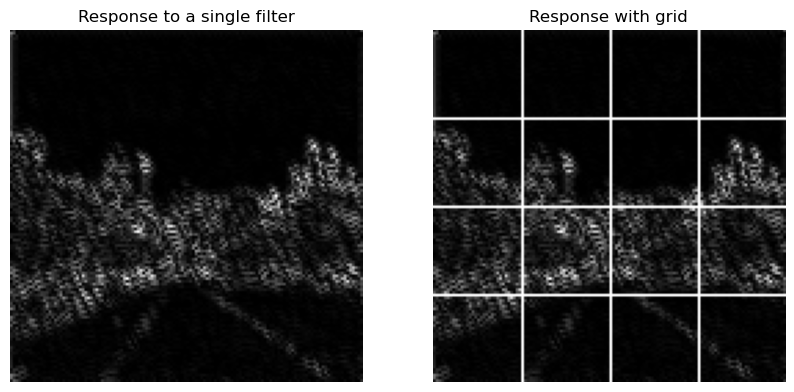

In [7]:
scale = 4
orientation = 1
response = np.abs(scipy.ndimage.correlate(grayscale, d.filters[:,:,scale, orientation], mode='constant'))

f = plt.gcf()

img = cv2.normalize(response, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
img = draw_grid(img, rows=4, cols=4)

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,20))

ax1.imshow(response, cmap='gray')
ax1.axis("off")
ax1.set_title("Response to a single filter")
ax2.imshow(img, cmap='gray')
ax2.axis("off")
ax2.set_title("Response with grid")

f.savefig("responseSIngleFilter.png", dpi=100)

#### Visualizing the response to all filters

Above, we visualized the response to a single Gabor filter. To obtain the GIST descriptors, each response is averaged into a 4x4 image and we have 30 filters. Displaying the 30 filters side by side would not be optimal for comparing the response of our image to our different filters. The DescGIST.display() function works as follows: For each pixel in our 4x4 image, we display the 30 values associated with each filter on a disc. This disc is divided into 30 regions: one region per filter.

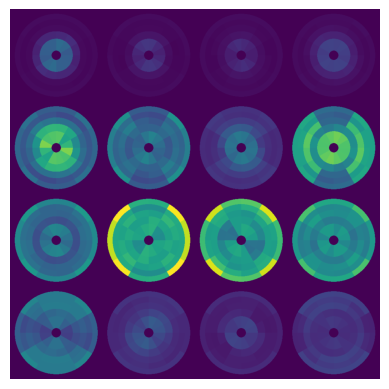

In [8]:
d.describe(grayscale)
res = d.display()
res.savefig("display.png")

### 1.4. Computing GIST descriptors on the whole database

In [9]:
def compare_images(data_path: str) -> np.ndarray:
    """Compares images and prints a seaborn array
    """
    objects = os.listdir(data_path)
    objects.sort()
    objects_names = [x.split('.')[0] for x in objects]
    descriptors = []

    print("Generating descriptors")
    for obj, name in tqdm(list(zip(objects, objects_names))):
        image = cv2.imread(os.path.join(data_path, obj))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        image = cv2.normalize(image, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
        descriptor = DescGIST()
        descriptor.get_all_gabors()
        descriptor.describe(image)
        descriptors.append(descriptor)
    print("Computing distances")
    n = len(descriptors)
    distances = np.zeros((n,n))
    for i, d1 in tqdm(enumerate(descriptors)):
        for j in range(i, n):
            dist = d1.distance(descriptors[j])
            distances[i,j] = dist
            distances[j,i] = dist

    sns.heatmap(distances, xticklabels=objects_names, yticklabels=objects_names)
    return distances

Generating descriptors


  0%|          | 0/13 [00:00<?, ?it/s]

Computing distances


0it [00:00, ?it/s]

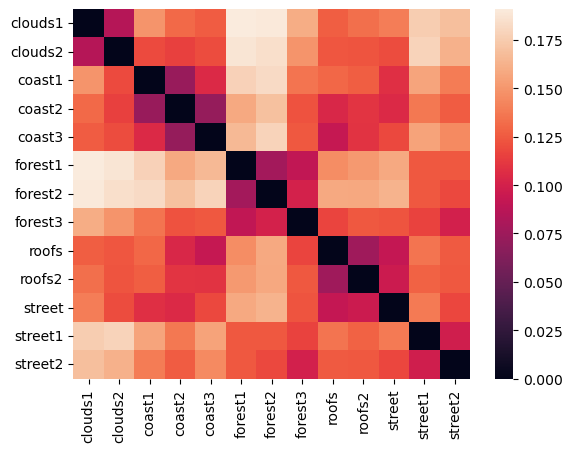

In [10]:
distances = compare_images(data_dir+'/testGist/')

### Finding the closest image to another image

In [11]:
objects = os.listdir(data_dir+"/testGist")
objects_names = [x.split('.')[0] for x in objects]
for i in range (len(distances)):
    obj = objects_names[i]
    dist = distances[i, :]
    dist[i] = np.inf
    best_match = np.argmin(dist)
    print(obj, "<->", objects_names[best_match])

clouds1 <-> clouds2
clouds2 <-> clouds1
coast1 <-> coast2
coast2 <-> coast3
coast3 <-> coast2
forest1 <-> forest2
forest2 <-> forest1
forest3 <-> forest1
roofs <-> roofs2
roofs2 <-> roofs
street <-> roofs
street1 <-> street2
street2 <-> street1


# 2. Poisson Blending 



The Poisson algorithm for image blending was first described in this article: [Poisson Image Editing [Perez et al. 2003]](https://www.cs.jhu.edu/~misha/Fall07/Papers/Perez03.pdf). Its idea is to paste the image into the Gradient space, then integrate it to obtain the result of the paste (a smooth blend). This integration can be approximated by Poisson's method, by solving the problem
\begin{equation}
    \Delta I = \nabla G
\end{equation}

where $\nabla G$ is the gradient of the source image and $\Delta I$ is the Laplacian of the target.

---

### Jacobi's method

The Poisson blending problem can be described as such :

"In the region to be inpainted, the laplacian of the target is equal to the divergence of the source."

To solve this problem , i used an algorithm called Jacobi's method, which converges towards a solution to the equation. To do so, the source image will be iteratively updated that way :

$I_{src}^{t+1} = Div(I_{src}^{t}) + \Delta I_{target}$

Where $Div(I)$ represents the result of the *divergence* operator (which simply results in every pixel being assigned the average value of its 4 neighbours).




In [12]:
def correlate(image: np.ndarray, kernel: np.ndarray, mode: str) -> np.ndarray:
    """Correlates an image with a kernel
    """
    result = np.empty_like(image)
    if len(image.shape) == 2:
        nChannels = 1
    else:
        nChannels = np.min(image.shape)
    for channel in range(nChannels):
        result[:, :, channel] = scipy.ndimage.correlate(image[:,:,channel], kernel, mode=mode)

    return result

In [13]:
def read_images_inpainting(src_path, target_path):
    """Reads inpainting data
    """

    # SRC image is a png. It has a fourth channel called transparency. To get the 4D image, load it using cv2.IMREAD_UNCHANGED
    # then extract the src image (BGR that we convert to RGB) and the transparency as two separate arrays
    src = cv2.imread(src_path, cv2.IMREAD_UNCHANGED)
    transparency = src[:,:,3]
    src = src[:,:,:3]
    src = cv2.cvtColor(src, cv2.COLOR_BGR2RGB)

    # extract the target array and convert it to RGB
    target = cv2.imread(target_path)
    target = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)

    # Having access to the transparency gives access to the pixels that have been shaded in the source image, vs the pixels that i want to keep intact. The latter will be stored in fixed_areas
    transparency = transparency / np.max(transparency)
    fixed_areas = transparency>0.5

    # scale the images to [0,1]
    src = src /255
    target = target /255

    return src, target, fixed_areas

In [14]:
def poisson_blending(src: np.ndarray, target: np.ndarray, fixed_areas: np.ndarray, nb_iter: int) -> np.ndarray:
    """
    This function computes the blended image between the src and target images,
    only in the ROI specified in the fixed_areas logical image.

    """
    # Initialize divergence kernel and laplacian kernel
    div_kernel = (1/4) * np.array([[0,1,0],
                                   [1,0,1],
                                   [0,1,0]])
    lap_kernel = np.array([[0, -0.25,0],
                           [-0.25, 1,-0.25],
                           [0,-0.25,0]])


    result = src.copy()
    update_mask = ~fixed_areas
    lap_target = correlate(target, lap_kernel, mode='reflect')

    for i in range(nb_iter):


        div_src = correlate(result, div_kernel, mode='reflect')


        new_result = result.copy()
        new_result[update_mask] = (div_src + lap_target)[update_mask]

        result = new_result

        if i % (nb_iter // 5) == 0 or i == nb_iter - 1:
            plt.figure(figsize=(6,6))
            plt.imshow(np.clip(result,0,1))
            plt.title(f"Iteration {i}")
            plt.axis("off")
            plt.show()

    return result




### Displaying results



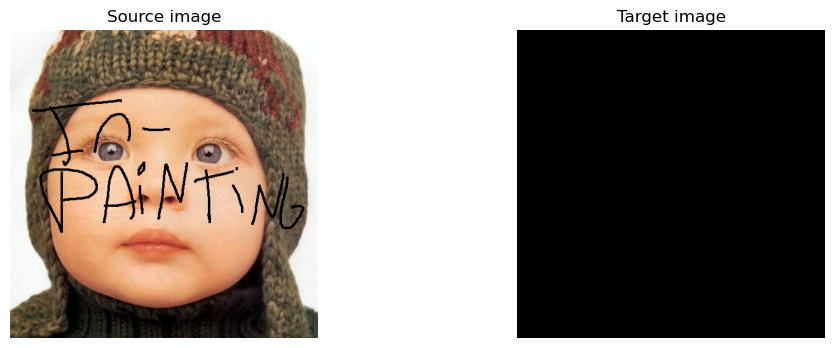

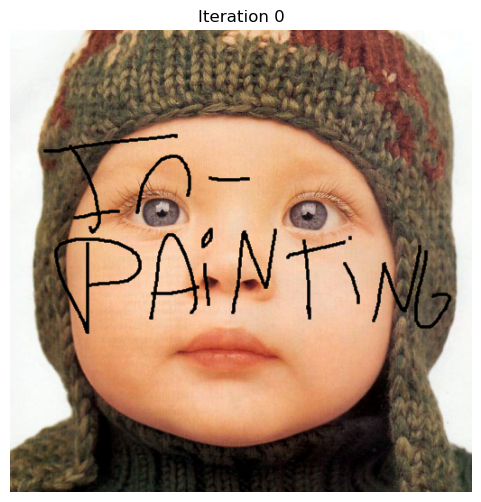

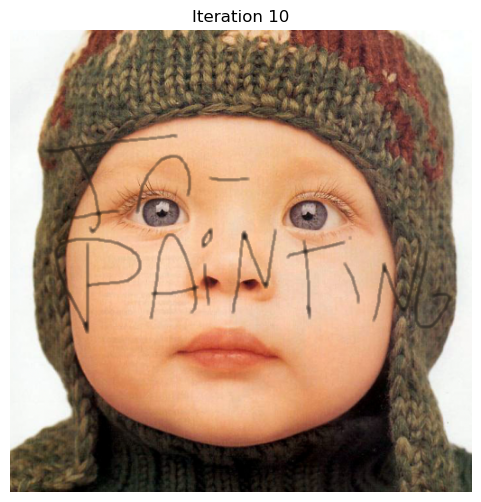

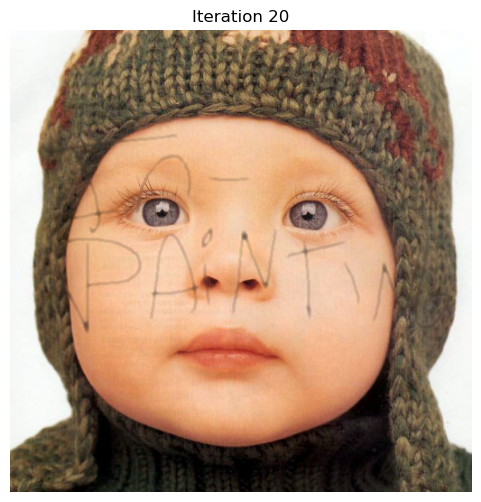

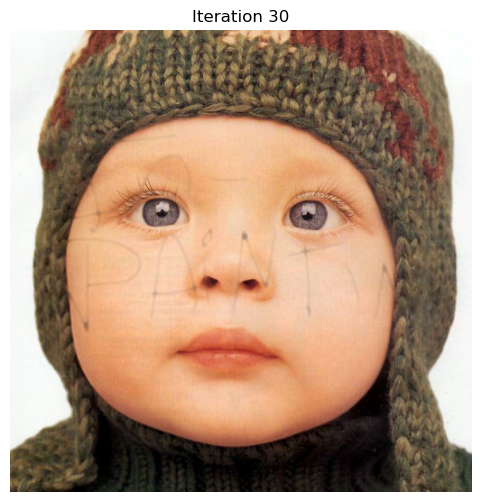

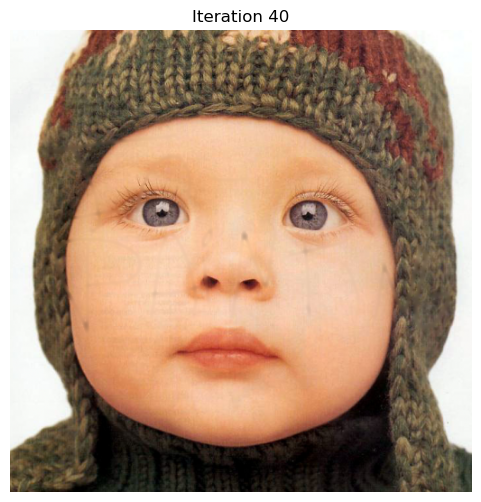

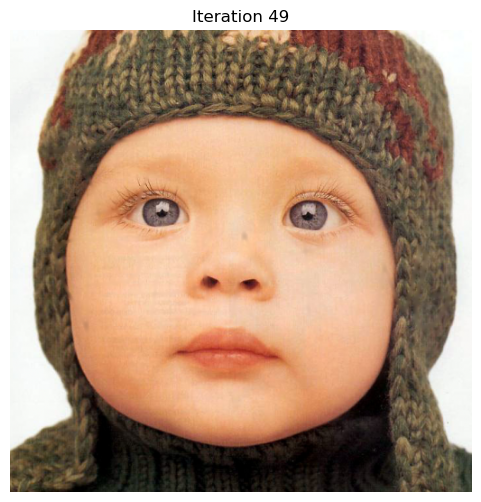

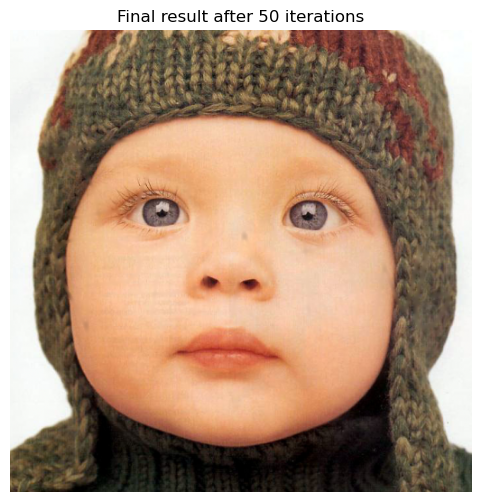

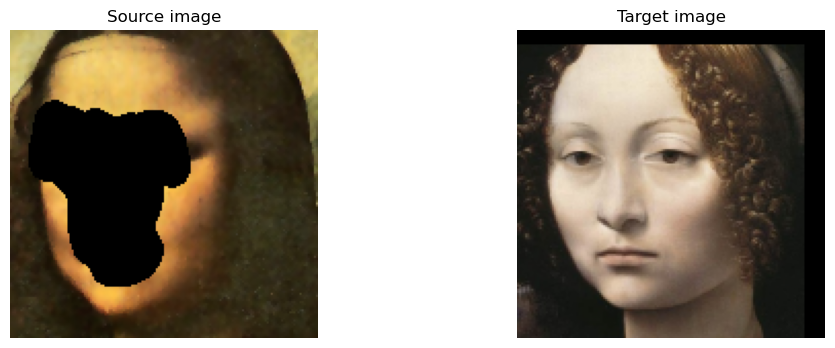

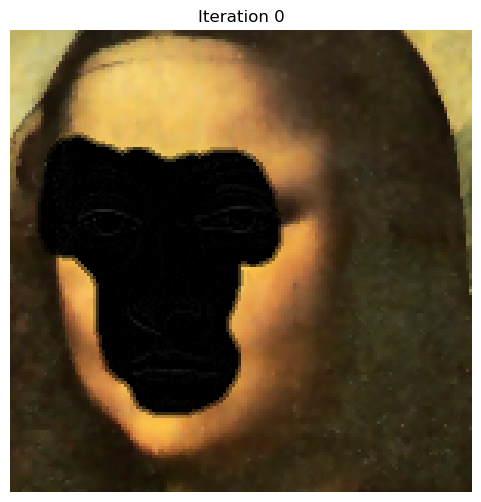

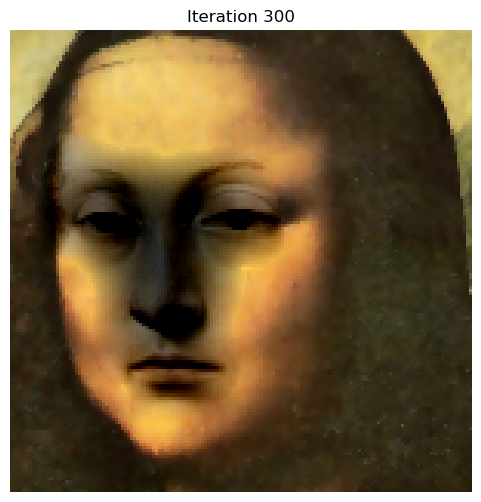

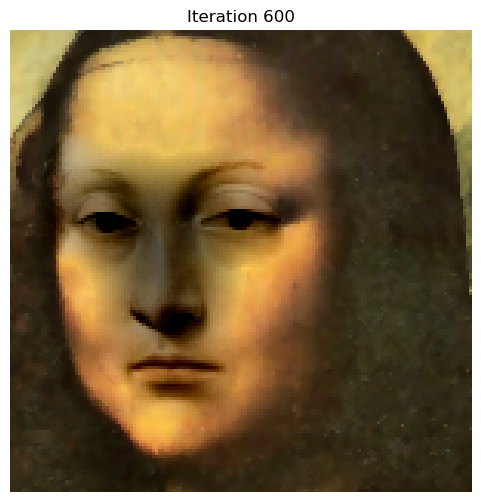

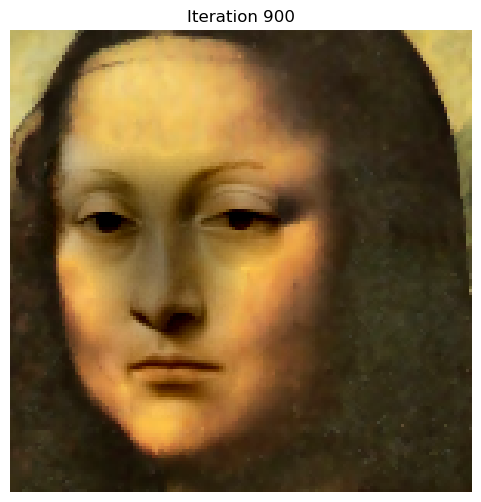

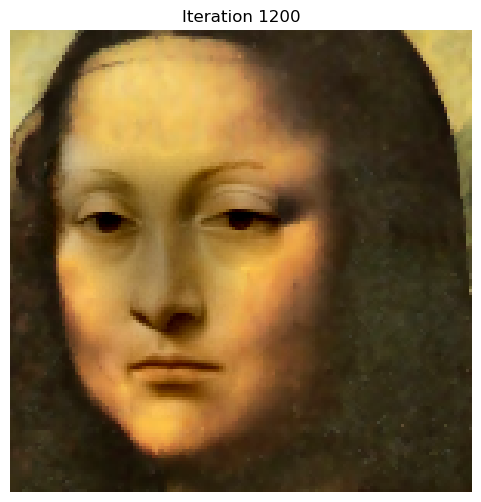

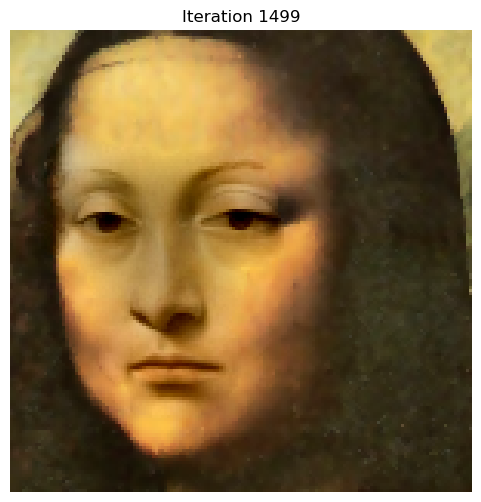

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3226296119483178..0.9921568627450981].


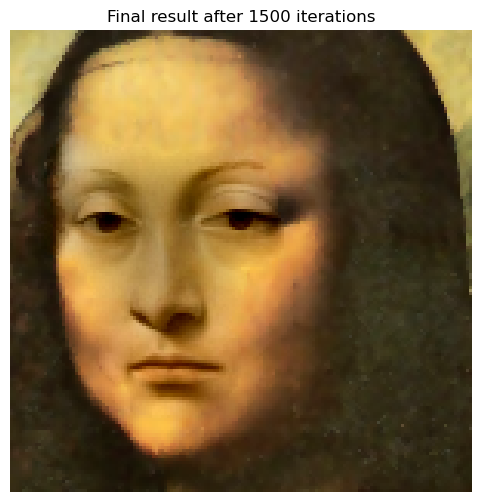

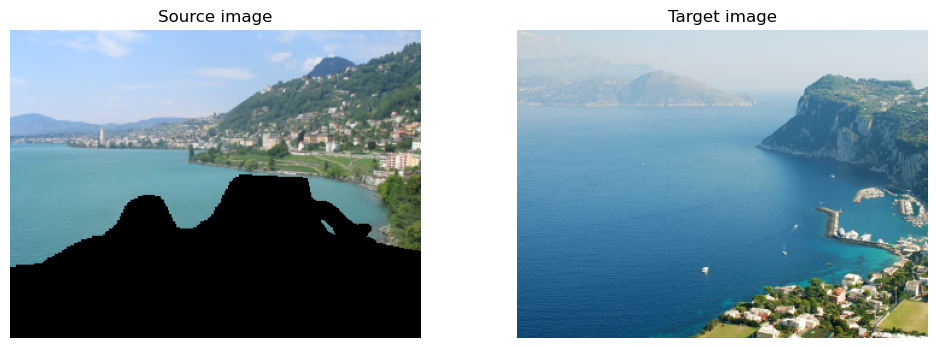

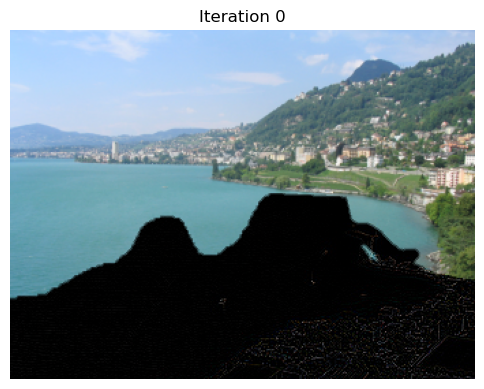

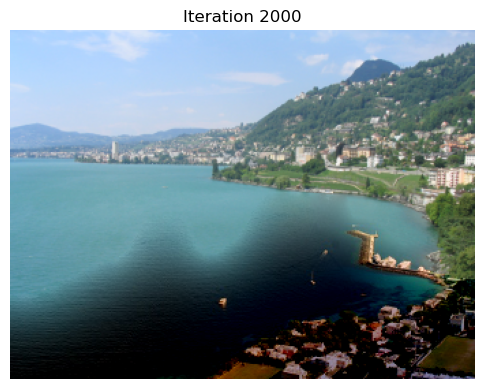

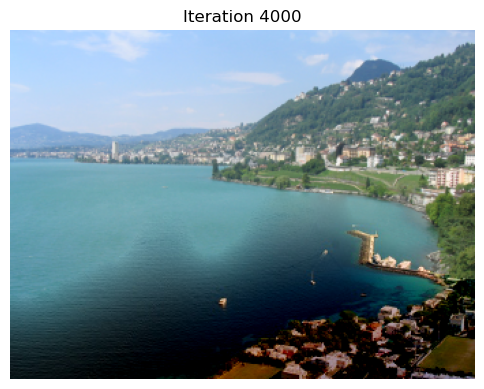

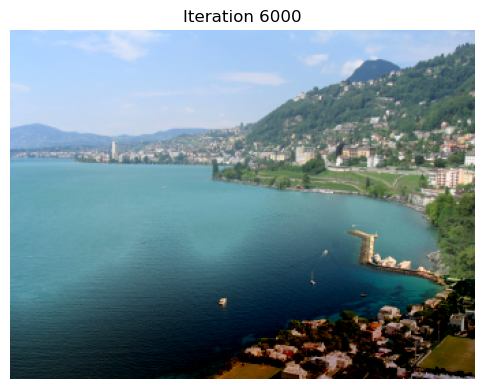

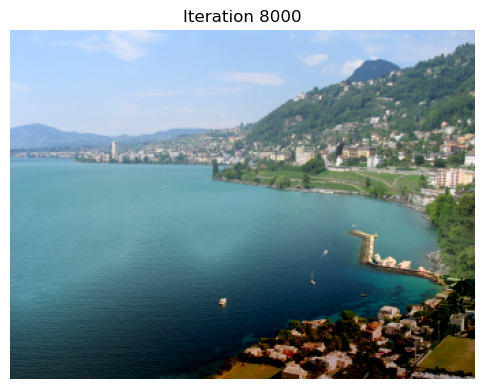

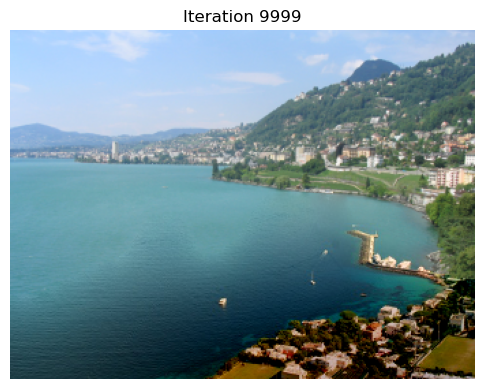

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3484770062667927..1.1247986404412131].


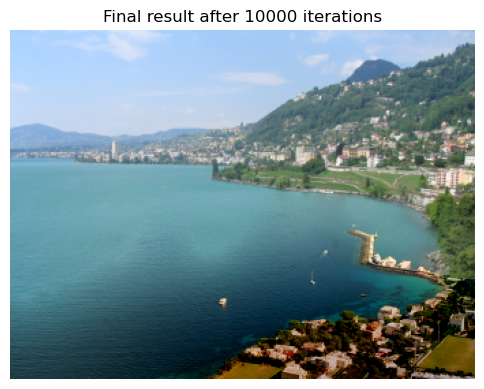

In [ ]:
tests = [
    (data_dir + "/testPoisson/test1/src.png", data_dir + "/testPoisson/test1/target.png"),
    (data_dir + "/testPoisson/test2/src.png", data_dir + "/testPoisson/test2/target.png"),
    (data_dir + "/testPoisson/test3/src.png", data_dir + "/testPoisson/test3/target.png"),
]


nb_iter = [50, 1500, 10000]

for i in range(3):

    src_path, target_path = tests[i]
    # Read images
    src, target, fixed_areas = read_images_inpainting(src_path, target_path)

    # plotting source and target
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.imshow(src)
    plt.title("Source image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(target)
    plt.title("Target image")
    plt.axis("off")

    plt.show()

    # Poisson blending

    result = poisson_blending(src, target, fixed_areas, nb_iter[i])

    # Final result
    plt.figure(figsize=(6,6))
    plt.imshow(result)
    plt.title(f"Final result after {nb_iter[i]} iterations")
    plt.axis("off")
    plt.show()